## 1. Importing the dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
import pickle

## 2. Data Loading and Understanding

In [2]:
# load the csv data to a pandas dataframe
data = pd.read_csv(r"C:\Users\arman\OneDrive\Desktop\Customer Churn Analysis & Prediction\Data\Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset Information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Check categorical columns
cat_cols = [col for col in data.columns if data[col].dtype=='str']
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [5]:
# Drop customerID column
data = data.drop(["customerID"], axis=1)

In [6]:
# Change TotalCharges to numeric datatype
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# display null value rows
data[np.isnan(data["TotalCharges"])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
# Drop rows where tenure is 0
data = data.drop(labels=data[data["tenure"]==0].index, axis=0)
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
data.shape

(7032, 20)

In [10]:
# printing the unique values in all the columns

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in data.columns:
  if col not in numerical_features_list:
    print(col, data[col].unique())
    print("-"*50)

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, 

In [11]:
# checking the class distribution of target column
print(data["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


## Insights:

1. Customer ID removed as it is not required for modelling.
2. No mmissing values in the dataset.
3. Missing values in the TotalCharges column were removed.
4. Class imbalance identified in the target Dataset slightly imbalanced, suggest to use sampling techniques to balance the dataset for Classification ML Model.

## 3. Exploratory Data Analysis

In [12]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


**Numerical Features - Analysis**

Understand the distribution of teh numerical features

In [13]:
def plot_histogram(data, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(data[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = data[column_name].mean()
  col_median = data[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

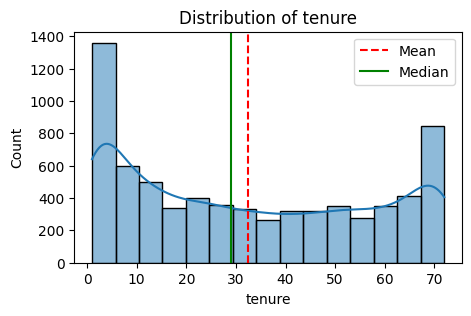

In [14]:
plot_histogram(data, "tenure")

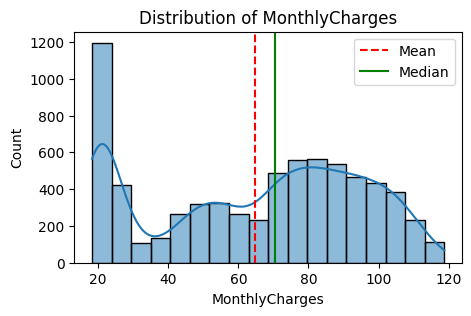

In [15]:
plot_histogram(data, "MonthlyCharges")

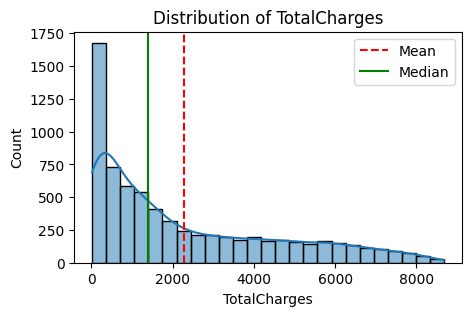

In [16]:
plot_histogram(data, "TotalCharges")

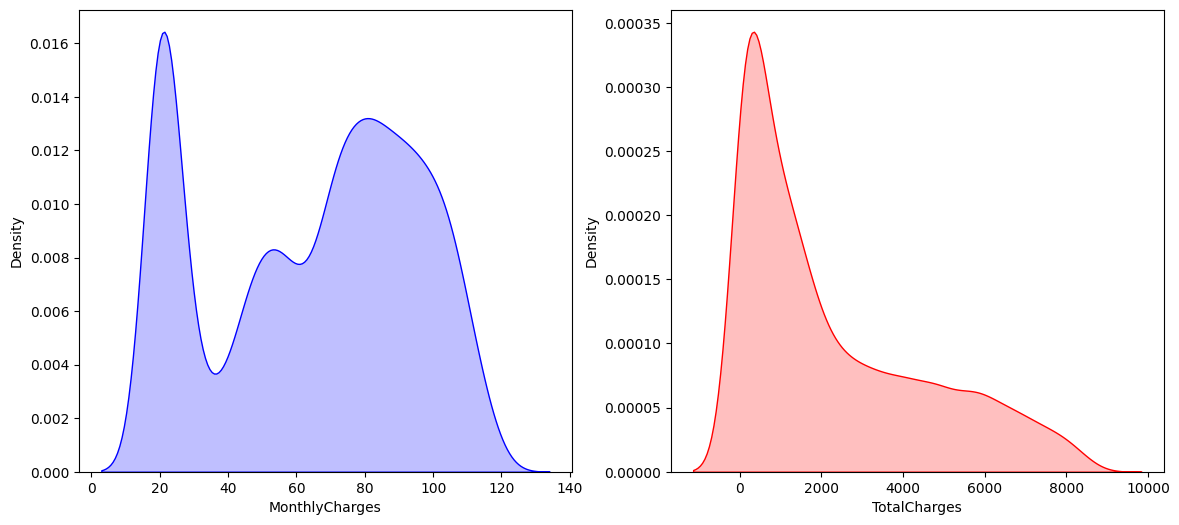

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.kdeplot(data["MonthlyCharges"], ax=axes[0], color='blue', shade=True);
sns.kdeplot(data["TotalCharges"], ax=axes[1], color='red', shade=True);

**Box plot for numerical features**

In [18]:
def plot_boxplot(data, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=data[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show

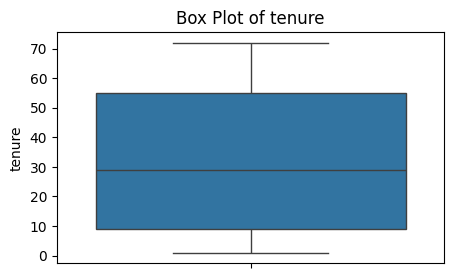

In [19]:
plot_boxplot(data, "tenure")

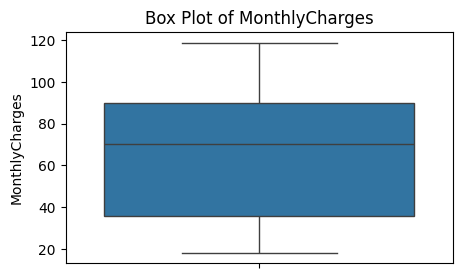

In [20]:
plot_boxplot(data, "MonthlyCharges")

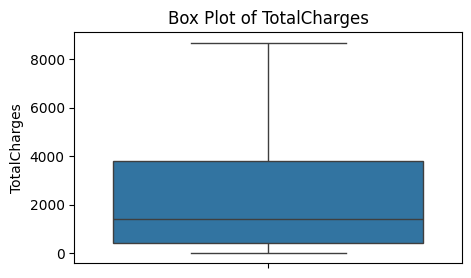

In [21]:
plot_boxplot(data, "TotalCharges")

**Correlation Heatmap for numerical columns**

<Axes: >

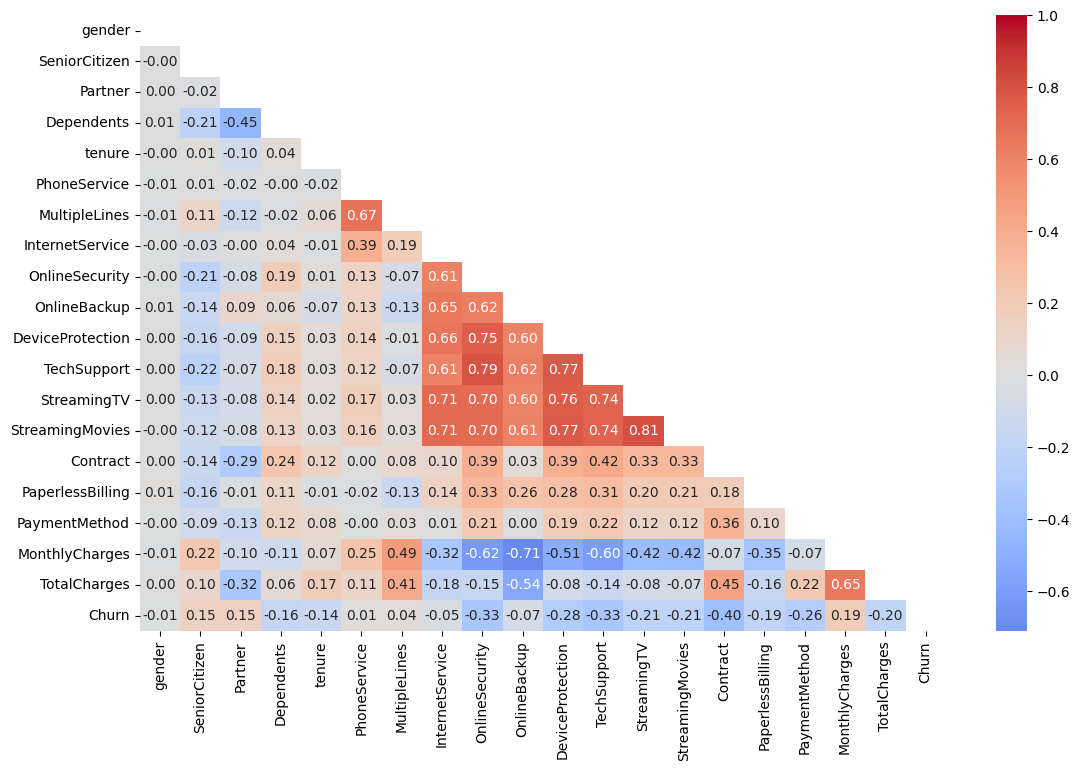

In [22]:
plt.figure(figsize=(13,8))
corr = data.apply(lambda x: pd.factorize(x)[0] if x.dtype!='float64' else x).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, center=0, annot=True, fmt='.2f')

**Categorical features - Analysis**

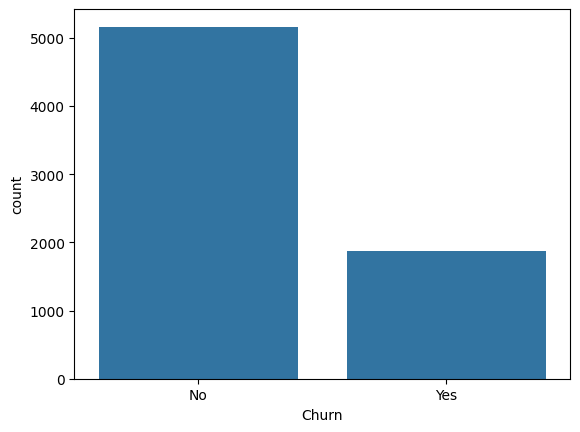

In [23]:
sns.countplot(x="Churn", data=data);

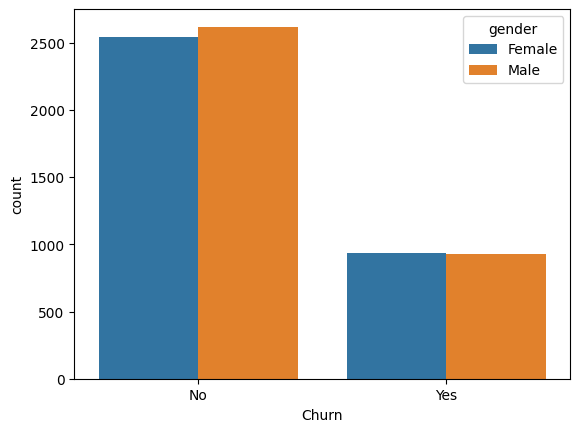

In [24]:
sns.countplot(x="Churn", hue="gender", data=data);

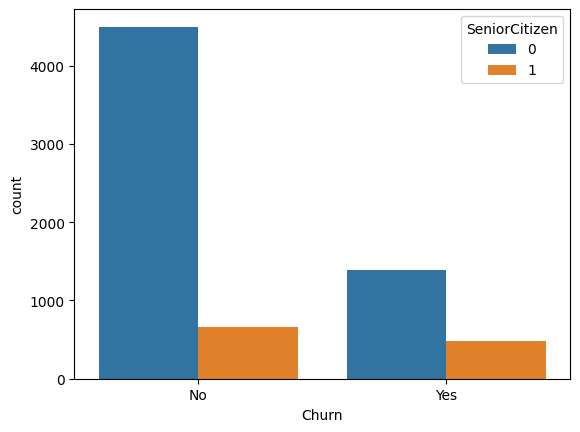

In [25]:
sns.countplot(x="Churn", hue="SeniorCitizen", data=data);

### Senior Citizen are more likely to churn

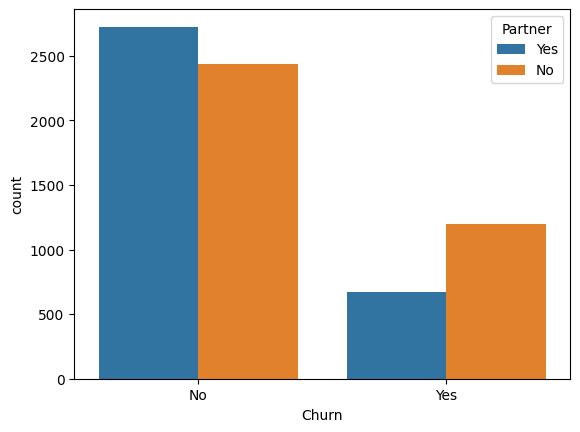

In [26]:
sns.countplot(x="Churn", hue="Partner", data=data);

### People who doesn't have partner or single person more like to get churn

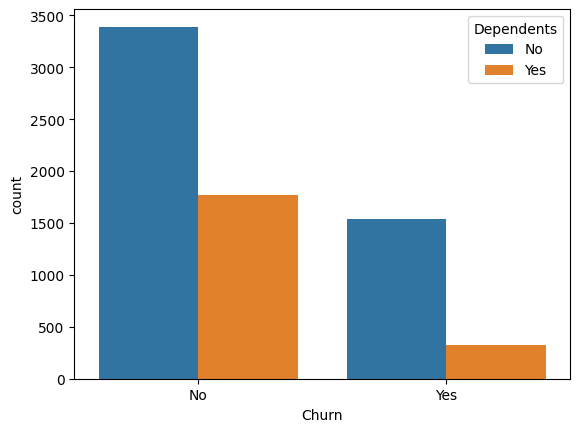

In [27]:
sns.countplot(x="Churn", hue="Dependents", data=data);

### People who doesn't have any dependents or single person more likely to churn
### If the customer has a family, all of them prefer to use same services and retention is high

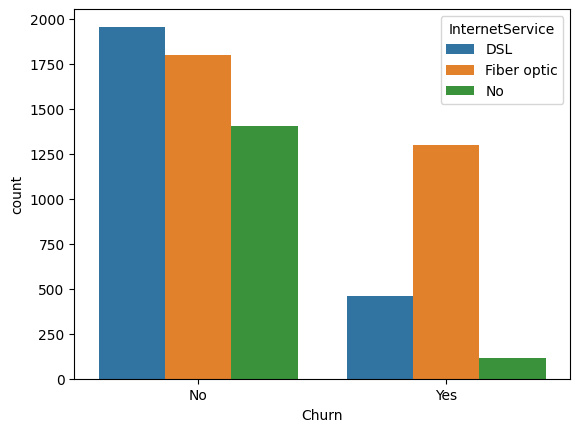

In [28]:
sns.countplot(x="Churn", hue="InternetService", data=data);

### Those who have opted for fiber optics are more likely to churn and on the contrary, those who have DSL service have more retention

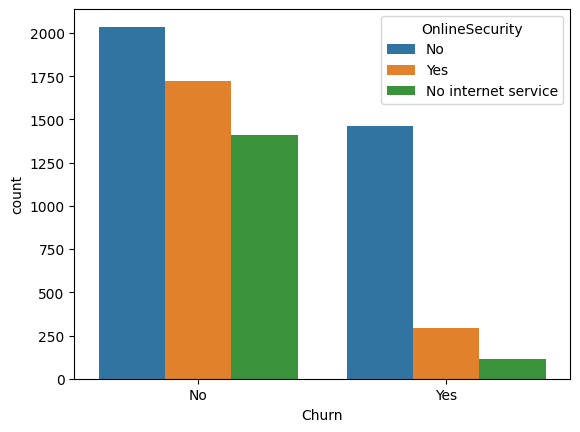

In [29]:
sns.countplot(x="Churn", hue="OnlineSecurity", data=data);

### People who doesn't have security are more likely to churn

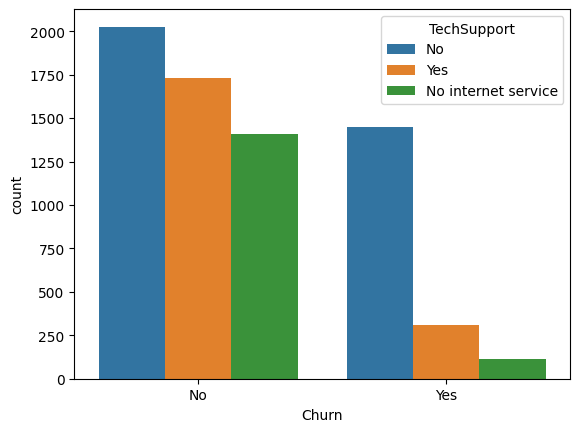

In [30]:
sns.countplot(x="Churn", hue="TechSupport", data=data);

### People who doesn't have Tech Support are more likely to churn

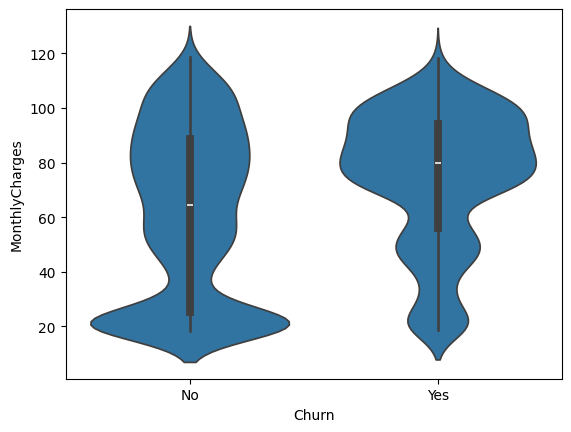

In [31]:
sns.violinplot(x="Churn", y="MonthlyCharges", data=data);

### People who have high monthly charges are more likely to churn

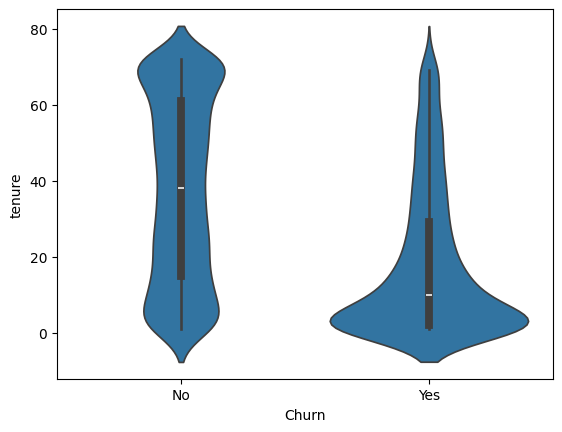

In [32]:
sns.violinplot(x="Churn", y="tenure", data=data);

### People who are on low tenure or who have subscribed for less no. of months are more likely to churn

## 4. Data Preprocessing

In [33]:
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


**Label encoding of target column**

In [34]:
data["Churn"] = data["Churn"].replace({"Yes": 1, "No": 0})

In [35]:
print(data["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


**Label encoding of categorical fetaures**

In [36]:
# 1. identifying columns with object data type
# object_columns = data.select_dtypes(include="str").columns
# object_columns

In [37]:
# 2. Check categorical columns
cat_cols = [col for col in data.columns if data[col].dtype=='str']
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [38]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for col in cat_cols:
  label_encoder = LabelEncoder()
  data[col] = label_encoder.fit_transform(data[col])
  encoders[col] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)
    
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [39]:
data.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0


In [40]:
data["MonthlyCharges"] = np.log(data["MonthlyCharges"]+1)
data["TotalCharges"] = np.log(data["TotalCharges"]+1)

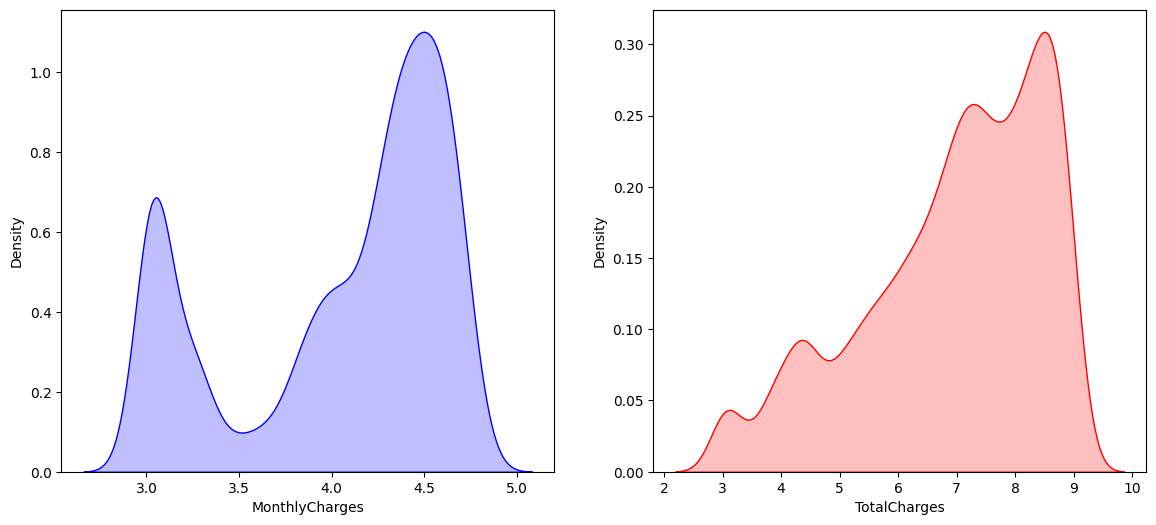

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.kdeplot(data["MonthlyCharges"], ax=axes[0], color='blue', shade=True);
sns.kdeplot(data["TotalCharges"], ax=axes[1], color='red', shade=True);

**Traianing and test data split**

In [42]:
# splitting the features and target
X = data.drop(columns=["Churn"])
y = data["Churn"]

In [43]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
print(y_train.shape)

(5625,)


In [45]:
print(y_train.value_counts())

Churn
0    4130
1    1495
Name: count, dtype: int64


In [46]:
print(y_train.dtype)

object


In [47]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

**Synthetic Minority Oversampling Technique (SMOTE)**

In [48]:
smote = SMOTE(random_state=42)

In [49]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [50]:
print(y_train_smote.shape)

(8260,)


In [51]:
print(y_train_smote.value_counts())

Churn
1    4130
0    4130
Name: count, dtype: int64


## 5. Model Training

**Training with default hyperparameters**

In [52]:
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [53]:
# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.85
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.84
----------------------------------------------------------------------


In [54]:
cv_scores

{'Decision Tree': array([0.70460048, 0.75605327, 0.81234867, 0.80992736, 0.81416465]),
 'Random Forest': array([0.77966102, 0.80811138, 0.8716707 , 0.88559322, 0.89285714]),
 'XGBoost': array([0.75      , 0.7905569 , 0.86985472, 0.88498789, 0.88438257])}

### Random Forest gives the highest accuracy 0.85 compared to other models with default parameters.

In [55]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
print(y_test.value_counts())

Churn
0    1033
1     374
Name: count, dtype: int64


## 6. Model Evaluation

In [57]:
# evaluate on test data
y_test_pred = rfc.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.7555081734186212
Confsuion Matrix:
 [[838 195]
 [149 225]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.54      0.60      0.57       374

    accuracy                           0.76      1407
   macro avg       0.69      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407



<Axes: >

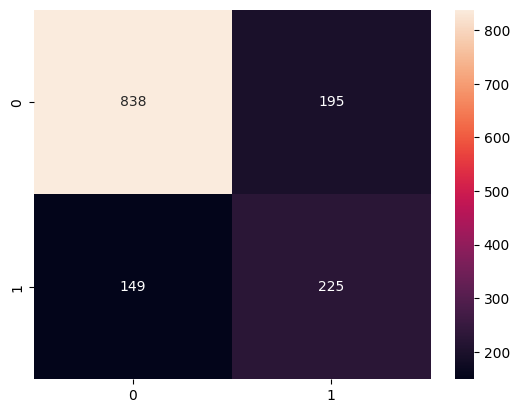

In [58]:
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')

In [59]:
# save the trained model as a pickle file
model_data = {"model": rfc, "features_names": X.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

## 7. Load the saved model and build a Predictive System

In [60]:
# load teh saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [61]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [62]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [63]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

[1]
Prediction: Churn
Prediciton Probability: [[0.26 0.74]]
